In [2]:
!pip install optuna -q

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import os
import pickle
from pathlib import Path
from collections import Counter

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    fbeta_score
)

import xgboost as xgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams["figure.dpi"] = 110

In [4]:
from google.colab import drive
drive.mount('gdrive')

Mounted at gdrive


In [5]:
DATA_DIR  = Path("Raw_Weather_Jakarta.csv")
MODEL_DIR = Path('/content/gdrive/MyDrive/Training Checkpoints/Flood_Model_Checkpoint')

In [6]:
df_raw = pd.read_csv(DATA_DIR)
df_raw.drop(columns=['ss', 'ff_x', 'ddd_car'], axis=1, inplace=True)

print(f"Shape : {df_raw.shape}")
df_raw.head()

Shape : (6308, 12)


,date,Tn,Tx,Tavg,RH_avg,RR,ddd_x,ff_avg,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,280.0,2.0,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,290.0,2.0,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,280.0,2.0,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,200.0,1.0,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,180.0,1.0,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          6308 non-null   object 
 1   Tn            5996 non-null   float64
 2   Tx            6095 non-null   float64
 3   Tavg          6262 non-null   float64
 4   RH_avg        6256 non-null   float64
 5   RR            3993 non-null   float64
 6   ddd_x         6286 non-null   float64
 7   ff_avg        6215 non-null   float64
 8   station_id    6308 non-null   int64  
 9   station_name  6308 non-null   object 
 10  region_name   6308 non-null   object 
 11  flood         6308 non-null   int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 591.5+ KB


In [8]:
df_raw.describe().round(2)

,Tn,Tx,Tavg,RH_avg,RR,ddd_x,ff_avg,station_id,flood
count,5996.00,6095.00,6262.00,6256.00,3993.00,6286.00,6215.00,6308.00,6308.00
mean,25.40,32.58,28.34,76.90,9.42,193.52,2.34,96741.05,0.08
std,3.23,5.57,1.80,9.72,18.46,109.21,1.86,5.24,0.26
min,2.40,21.30,23.70,34.00,0.00,0.00,0.00,96733.00,0.00
25%,24.40,31.80,27.70,72.00,0.00,80.00,1.00,96733.00,0.00
50%,25.00,32.60,28.40,77.00,1.40,230.00,2.00,96741.00,0.00
75%,26.00,33.40,29.10,82.00,10.50,280.00,3.00,96745.00,0.00
max,246.00,334.00,141.60,488.00,277.50,360.00,82.00,96747.00,1.00


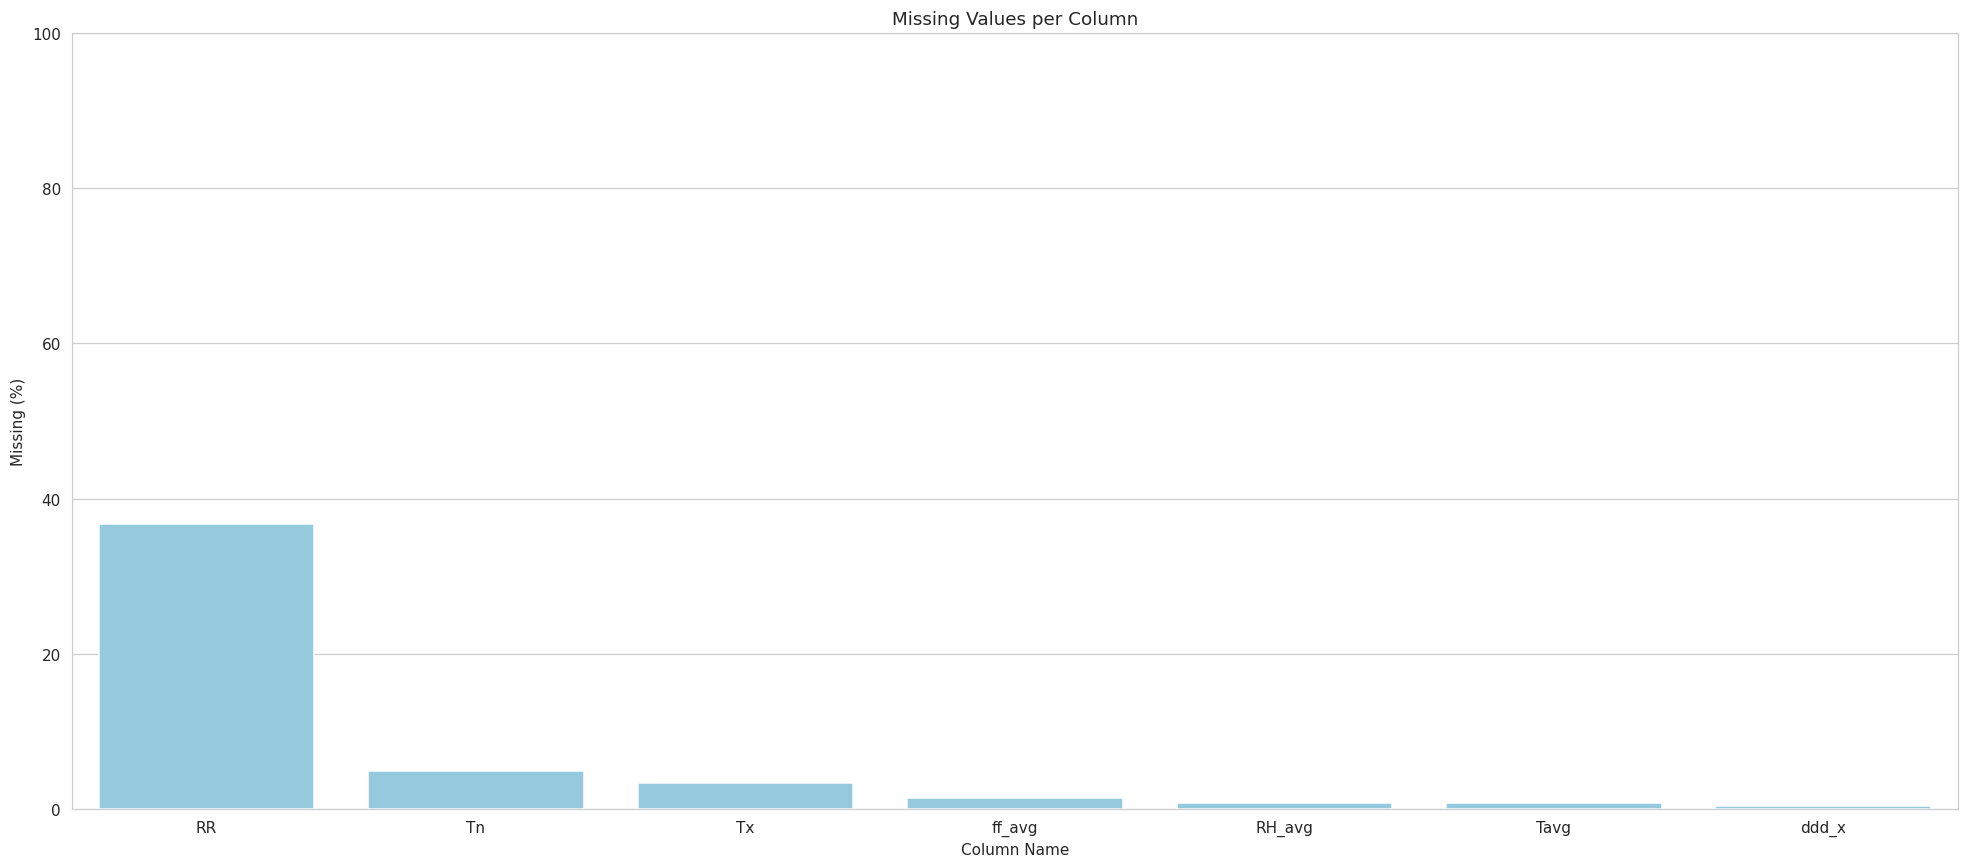

In [9]:
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(18, 8))
sns.barplot(missing, color='skyblue')
plt.title("Missing Values per Column")
plt.xlabel("Column Name")
plt.ylabel("Missing (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

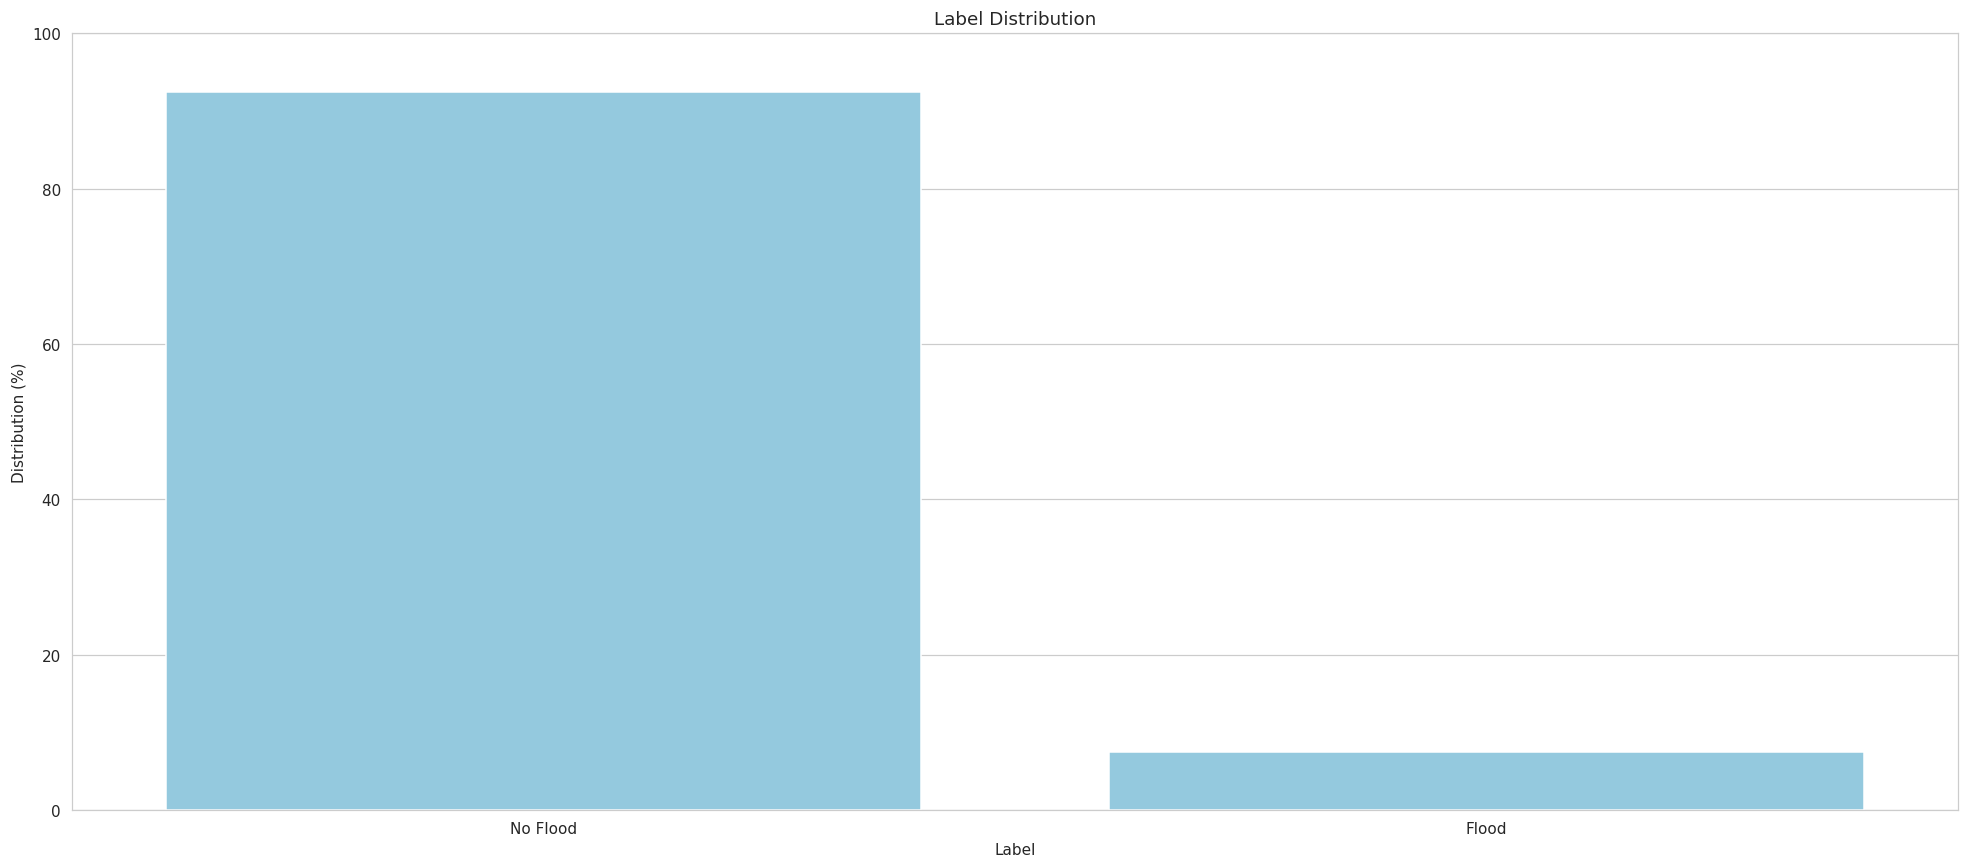

In [10]:
label_counter = Counter(df_raw['flood'])
label_count = {label: count/len(df_raw) * 100 for label, count in zip(['No Flood', 'Flood'], label_counter.values())}

plt.figure(figsize=(18, 8))
sns.barplot(label_count, color='skyblue')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Distribution (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


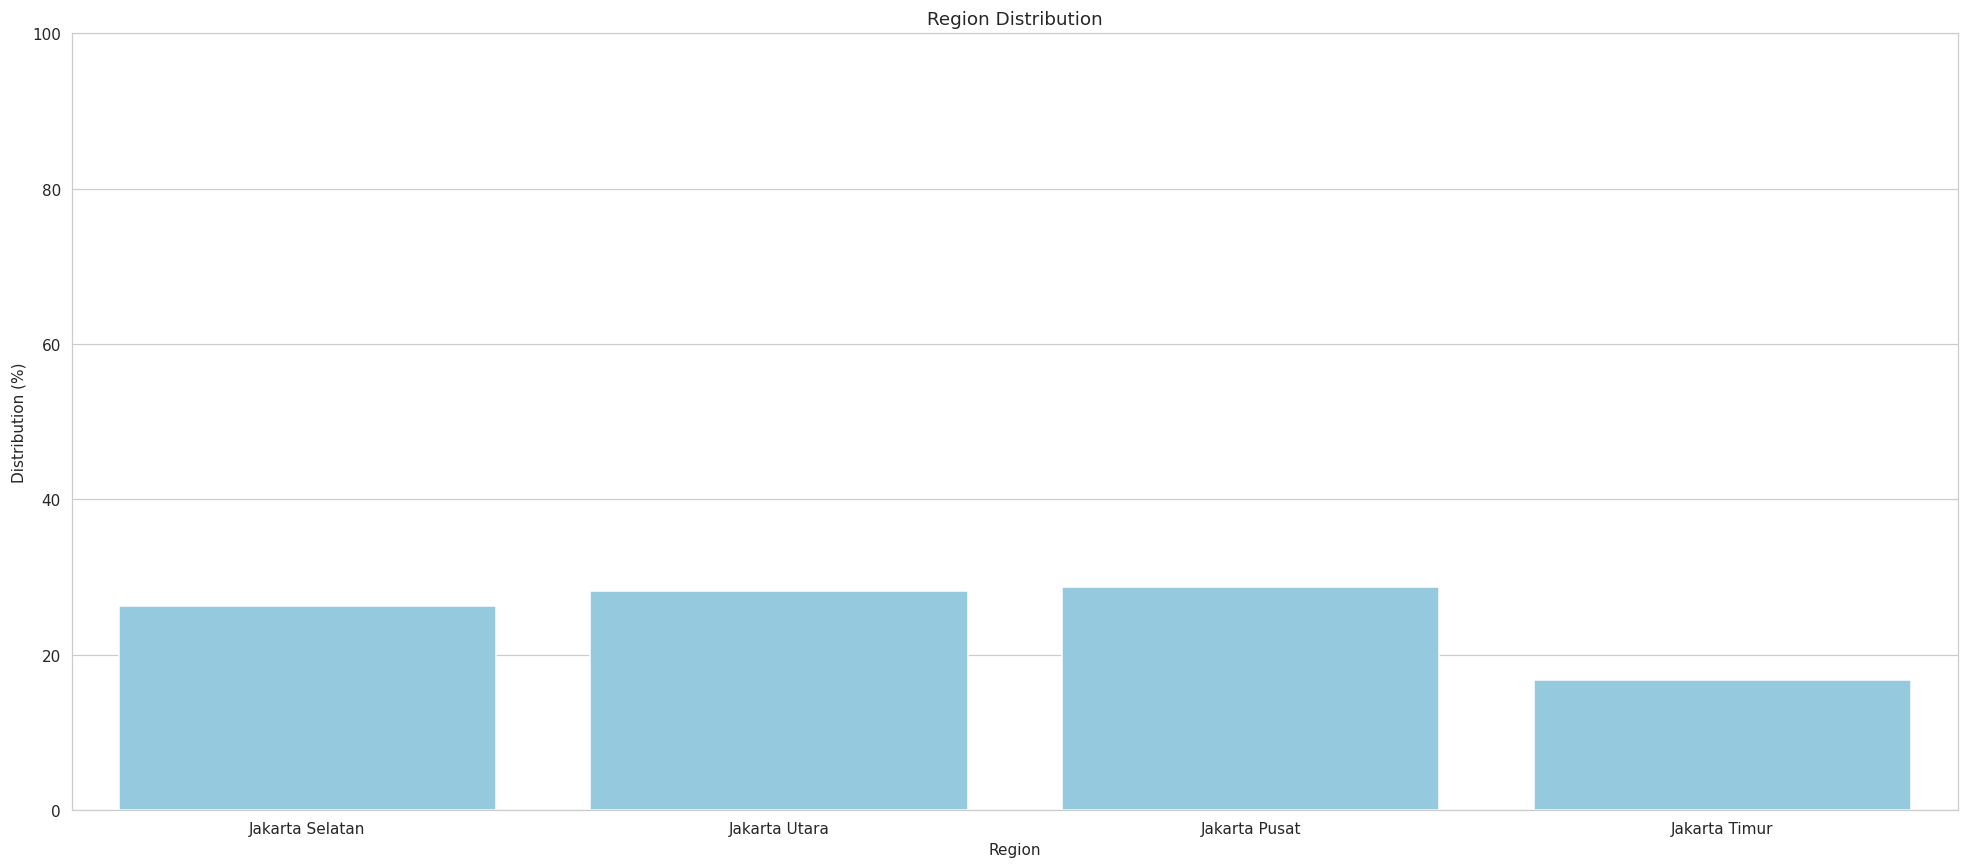

In [11]:
region_counter = Counter(df_raw['region_name'])
region_count = {region: count/len(df_raw) * 100 for region, count in region_counter.items()}

plt.figure(figsize=(18, 8))
sns.barplot(region_count, color='skyblue')
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Distribution (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

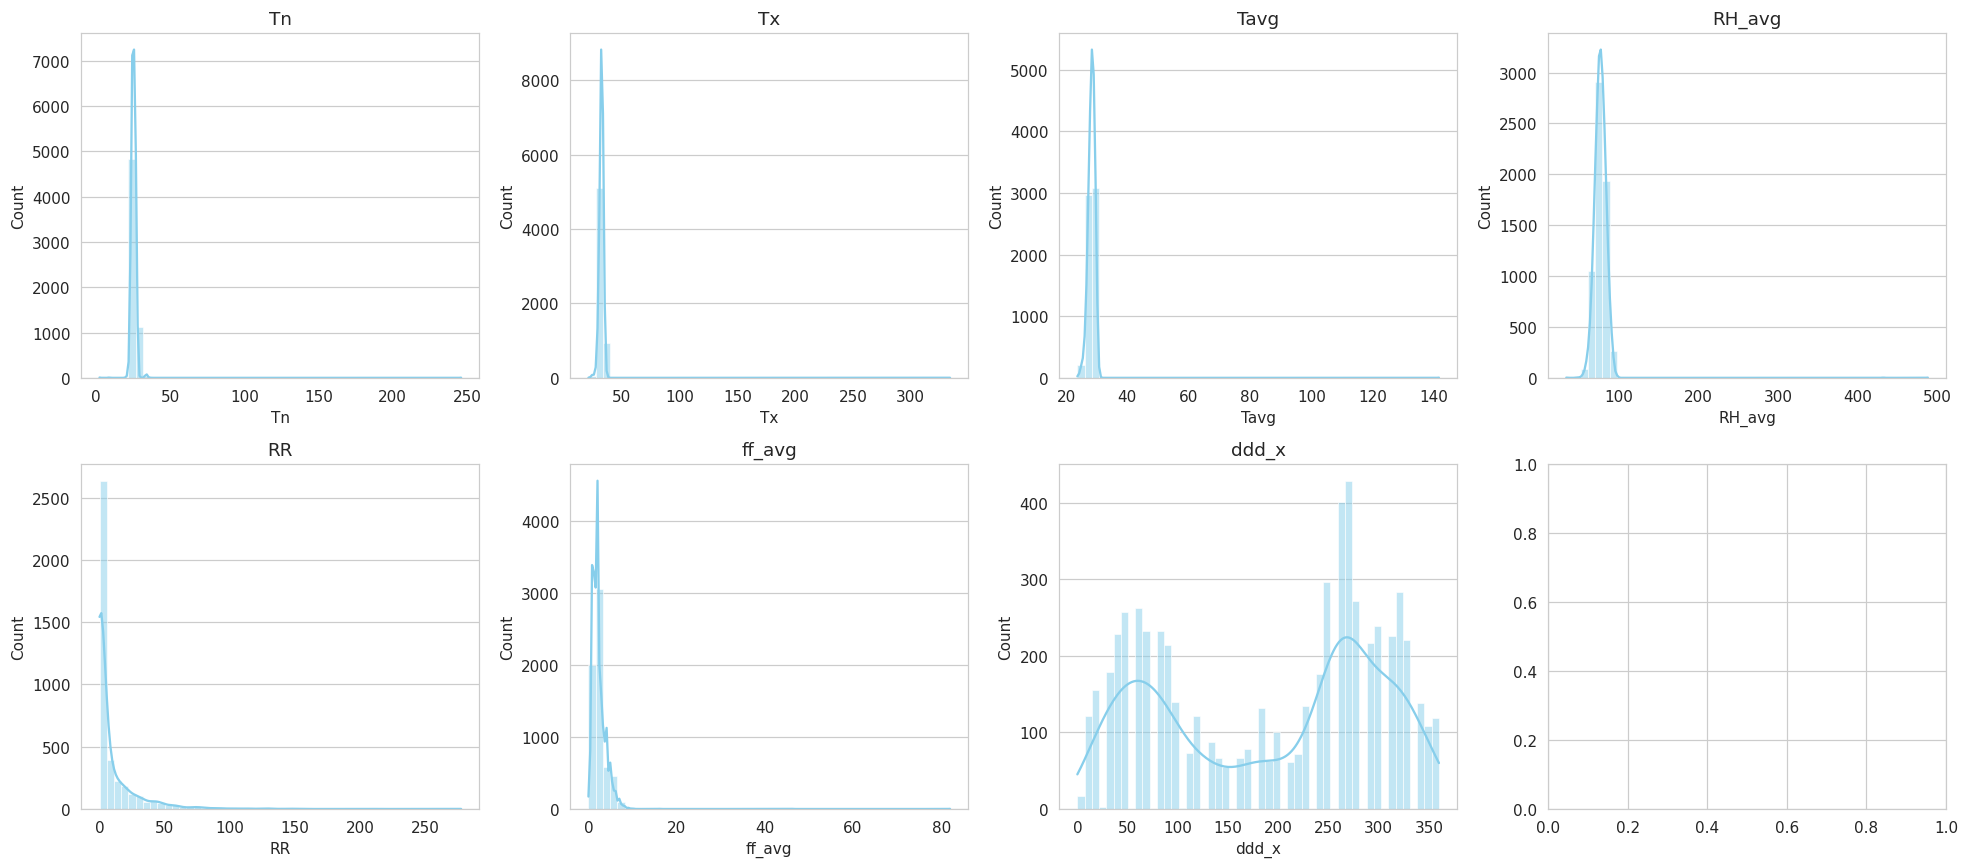

In [12]:
num_cols = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ff_avg', 'ddd_x']
corr_num = df_raw[num_cols + ['flood']].corr()['flood'].drop('flood').sort_values()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_raw[col], bins=50, kde=True, color='skyblue', ax=axes[i])
    axes[i].grid(False, axis='x')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

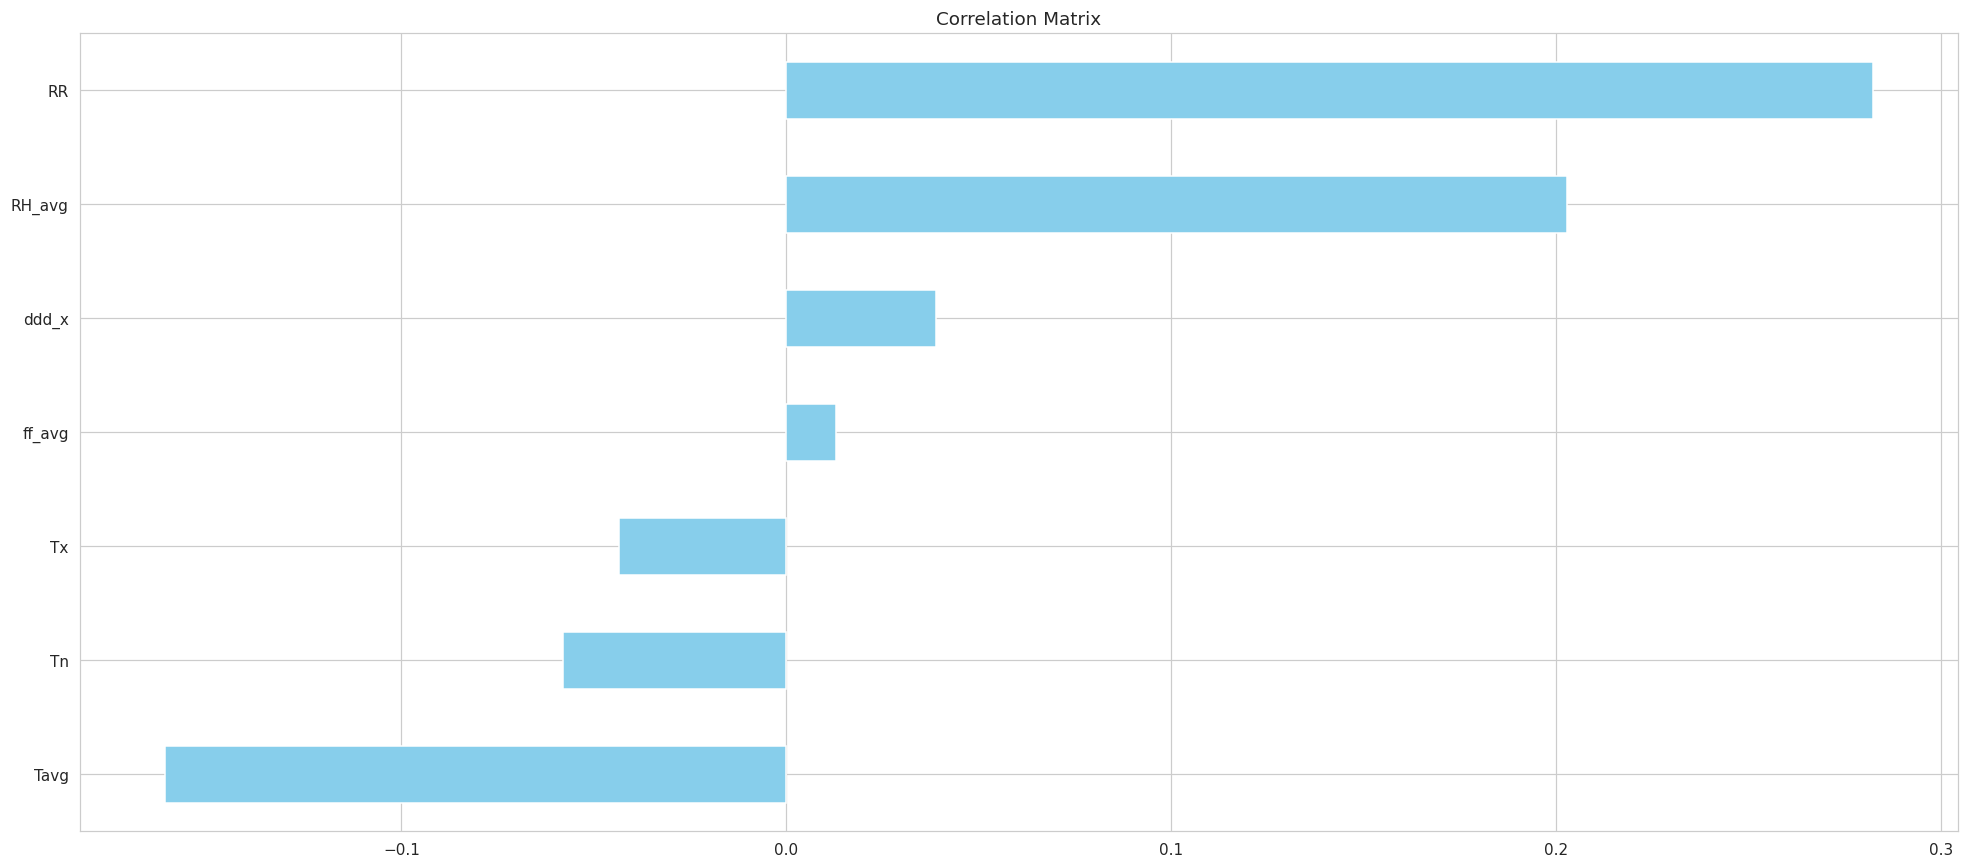

In [13]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.set_title("Correlation Matrix")
corr_num.plot.barh(color='skyblue', ax=ax)

plt.tight_layout()
plt.show()

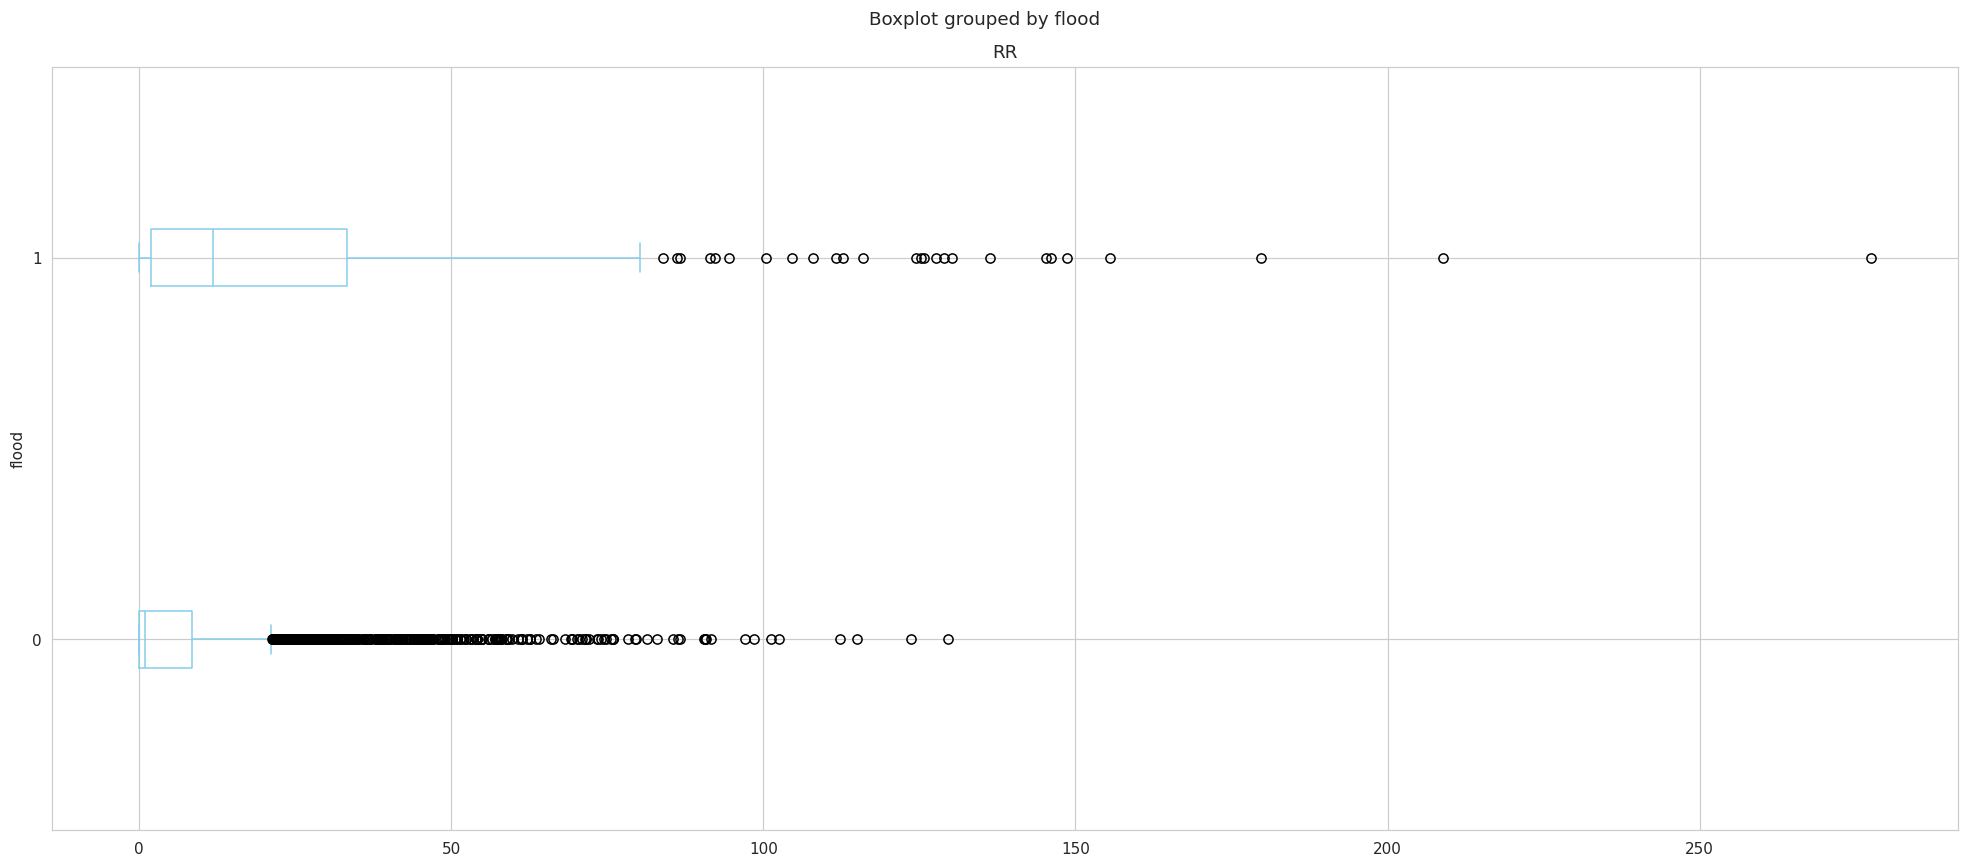

In [14]:
fig, ax = plt.subplots(figsize=(18, 8))

df_raw.boxplot(column="RR", by="flood", color='skyblue', ax=ax, vert=False)

plt.tight_layout()
plt.show()

In [15]:
df = df_raw.copy()
df.drop(columns=['station_name', 'station_id'], inplace=True)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['region_name', 'date']).reset_index(drop=True)

df.head()

,date,Tn,Tx,Tavg,RH_avg,RR,ddd_x,ff_avg,region_name,flood
0,2016-01-01,25.0,31.4,28.2,83.0,26.6,290.0,2.0,Jakarta Pusat,0
1,2016-01-02,26.0,31.0,27.1,85.0,0.0,300.0,1.0,Jakarta Pusat,0
2,2016-01-03,25.0,32.6,28.4,79.0,15.6,280.0,2.0,Jakarta Pusat,0
3,2016-01-04,NaN,31.6,29.0,80.0,0.0,300.0,2.0,Jakarta Pusat,0
4,2016-01-05,27.0,31.8,28.6,83.0,0.0,350.0,1.0,Jakarta Pusat,0


In [16]:
le_region = LabelEncoder()
df['region_id'] = le_region.fit_transform(df['region_name'].astype(str))
df.drop(columns=['region_name'], inplace=True)

region_map = dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))

df.head()

,date,Tn,Tx,Tavg,RH_avg,RR,ddd_x,ff_avg,flood,region_id
0,2016-01-01,25.0,31.4,28.2,83.0,26.6,290.0,2.0,0,0
1,2016-01-02,26.0,31.0,27.1,85.0,0.0,300.0,1.0,0,0
2,2016-01-03,25.0,32.6,28.4,79.0,15.6,280.0,2.0,0,0
3,2016-01-04,NaN,31.6,29.0,80.0,0.0,300.0,2.0,0,0
4,2016-01-05,27.0,31.8,28.6,83.0,0.0,350.0,1.0,0,0


In [17]:
df['RR'] = df['RR'].fillna(0.0)

for col in num_cols:
    df[col] = df.groupby('region_id')[col].transform(lambda x: x.ffill().bfill())
    df[col] = df[col].fillna(df[col].mean())

for col in num_cols:
    df[col] = df.groupby("region_id")[col].transform(lambda x: x.ffill().bfill())
    df[col] = df[col].fillna(df[col].mean())

df['wind_direction_rad'] = np.deg2rad(df['ddd_x'])
df['wind_direction_sin'] = np.sin(df['wind_direction_rad']).fillna(0)
df['wind_direction_cos'] = np.cos(df['wind_direction_rad']).fillna(1)
df.drop(columns=['wind_direction_rad', 'ddd_x'], inplace=True)

df.isnull().sum()


,0
date,0
Tn,0
Tx,0
Tavg,0
RH_avg,0
RR,0
ff_avg,0
flood,0
region_id,0
wind_direction_sin,0


# **Feature Engineering**

In [18]:
def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['month']       = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month_sin']   = np.sin(2 * np.pi * df['month']       / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month']       / 12)
    df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
    df.drop(columns=['month', 'day_of_year'], inplace=True)

    grp = df.groupby('region_id')['RR']

    df['rainfall_lag1d']  = grp.shift(1).fillna(0.0)
    df['rainfall_lag3d']  = grp.shift(3).fillna(0.0)
    df['rainfall_lag7d']  = grp.shift(7).fillna(0.0)

    df['rainfall_rolling3d_sum']  = grp.transform(lambda s: s.rolling(3,  min_periods=1).sum())
    df['rainfall_rolling7d_sum']  = grp.transform(lambda s: s.rolling(7,  min_periods=1).sum())
    df['rainfall_rolling14d_sum'] = grp.transform(lambda s: s.rolling(14, min_periods=1).sum())
    df['rainfall_rolling3d_max']  = grp.transform(lambda s: s.rolling(3,  min_periods=1).max())
    df['rainfall_rolling7d_max']  = grp.transform(lambda s: s.rolling(7,  min_periods=1).max())
    df['rainfall_rolling7d_std']  = grp.transform(
        lambda s: s.rolling(7, min_periods=2).std()
    ).fillna(0.0)

    grp_rh = df.groupby('region_id')['RH_avg']
    df['humidity_rolling3d_mean'] = grp_rh.transform(lambda s: s.rolling(3, min_periods=1).mean())
    df['humidity_rolling7d_mean'] = grp_rh.transform(lambda s: s.rolling(7, min_periods=1).mean())

    rain_cols = [c for c in df.columns if 'rainfall' in c]
    for col in rain_cols:
        df[col] = np.log1p(df[col])

    return df

df = feature_engineer(df)

print(f'Shape after FE : {df.shape}')
df.head()

Shape after FE : (6308, 26)


,date,Tn,Tx,Tavg,RH_avg,RR,ff_avg,flood,region_id,wind_direction_sin,...,rainfall_lag3d,rainfall_lag7d,rainfall_rolling3d_sum,rainfall_rolling7d_sum,rainfall_rolling14d_sum,rainfall_rolling3d_max,rainfall_rolling7d_max,rainfall_rolling7d_std,humidity_rolling3d_mean,humidity_rolling7d_mean
0,2016-01-01,25.0,31.4,28.2,83.0,26.6,2.0,0,0,-0.939693,...,0.000000,0.0,3.317816,3.317816,3.317816,3.317816,3.317816,0.000000,83.000000,83.000000
1,2016-01-02,26.0,31.0,27.1,85.0,0.0,1.0,0,0,-0.866025,...,0.000000,0.0,3.317816,3.317816,3.317816,3.317816,3.317816,2.986138,84.000000,84.000000
2,2016-01-03,25.0,32.6,28.4,79.0,15.6,2.0,0,0,-0.984808,...,0.000000,0.0,3.765840,3.765840,3.765840,3.317816,3.317816,2.664873,82.333333,82.333333
3,2016-01-04,25.0,31.6,29.0,80.0,0.0,2.0,0,0,-0.866025,...,3.317816,0.0,2.809403,3.765840,3.765840,2.809403,3.317816,2.637875,81.333333,81.750000
4,2016-01-05,27.0,31.8,28.6,83.0,0.0,1.0,0,0,-0.173648,...,0.000000,0.0,2.809403,3.765840,3.765840,2.809403,3.317816,2.579745,80.666667,82.000000


In [19]:
FEATURE_COL = [
    'Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ff_avg',
    'region_id', 'wind_direction_sin', 'wind_direction_cos',
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'rainfall_lag1d', 'rainfall_lag3d', 'rainfall_lag7d',
    'rainfall_rolling3d_sum', 'rainfall_rolling7d_sum',
    'rainfall_rolling14d_sum','rainfall_rolling3d_max',
    'rainfall_rolling7d_max','rainfall_rolling7d_std',
    'humidity_rolling3d_mean', 'humidity_rolling7d_mean'
]

TARGET_COL  = 'flood'

print(FEATURE_COL)
print(TARGET_COL)

['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ff_avg', 'region_id', 'wind_direction_sin', 'wind_direction_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'rainfall_lag1d', 'rainfall_lag3d', 'rainfall_lag7d', 'rainfall_rolling3d_sum', 'rainfall_rolling7d_sum', 'rainfall_rolling14d_sum', 'rainfall_rolling3d_max', 'rainfall_rolling7d_max', 'rainfall_rolling7d_std', 'humidity_rolling3d_mean', 'humidity_rolling7d_mean']
flood


In [20]:
df_model = df.copy().sort_values('date').reset_index(drop=True)

n           = len(df_model)
train_end   = int(n * 0.70)
val_end     = int(n * 0.85)

df_train = df_model.iloc[:train_end]
df_val   = df_model.iloc[train_end:val_end]
df_test  = df_model.iloc[val_end:]

print(f'Train : {len(df_train):>6,} rows | {df_train["date"].min().date()} → {df_train["date"].max().date()}')
print(f'Val   : {len(df_val):>6,} rows | {df_val["date"].min().date()} → {df_val["date"].max().date()}')
print(f'Test  : {len(df_test):>6,} rows | {df_test["date"].min().date()} → {df_test["date"].max().date()}')
print(f'\nFlood rate — Train: {df_train[TARGET_COL].mean():.2%}  '
      f'Val: {df_val[TARGET_COL].mean():.2%}  Test: {df_test[TARGET_COL].mean():.2%}')

Train :  4,415 rows | 2016-01-01 → 2019-03-28
Val   :    946 rows | 2019-03-29 → 2020-02-07
Test  :    947 rows | 2020-02-07 → 2020-12-31

Flood rate — Train: 8.04%  Val: 3.81%  Test: 8.98%


In [21]:
X_train = df_train[FEATURE_COL].values
y_train = df_train[TARGET_COL].values

X_val   = df_val[FEATURE_COL].values
y_val   = df_val[TARGET_COL].values

X_test  = df_test[FEATURE_COL].values
y_test  = df_test[TARGET_COL].values

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [22]:
sample_weight = compute_sample_weight("balanced", y_train)

baseline_model = xgb.XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
)

baseline_model.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_val, y_val)],
    verbose       = 50
)

[0]	validation_0-logloss:0.66097
[50]	validation_0-logloss:0.24231
[100]	validation_0-logloss:0.19602
[150]	validation_0-logloss:0.17347
[200]	validation_0-logloss:0.15978
[250]	validation_0-logloss:0.14805
[299]	validation_0-logloss:0.14164


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
def evaluate(model, X, y, label="Set"):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    auc     = roc_auc_score(y, y_proba)
    ap      = average_precision_score(y, y_proba)

    print(f"\n-{label}")
    print(f"ROC_AUC           : {auc:.4f}")
    print(f"Average Precision : {ap:.4f}")
    print(classification_report(y, y_pred, target_names=['No Flood', "Flood"]))

    return y_pred, y_proba

_, _ = evaluate(baseline_model, X_train, y_train, "Train")
val_pred_base, val_proba_base = evaluate(baseline_model, X_val, y_val, "Validation")



-Train
ROC_AUC           : 1.0000
Average Precision : 1.0000
              precision    recall  f1-score   support

    No Flood       1.00      0.99      1.00      4060
       Flood       0.92      1.00      0.96       355

    accuracy                           0.99      4415
   macro avg       0.96      1.00      0.98      4415
weighted avg       0.99      0.99      0.99      4415


-Validation
ROC_AUC           : 0.8934
Average Precision : 0.2960
              precision    recall  f1-score   support

    No Flood       0.98      0.96      0.97       910
       Flood       0.30      0.44      0.36        36

    accuracy                           0.94       946
   macro avg       0.64      0.70      0.66       946
weighted avg       0.95      0.94      0.95       946



In [24]:
def objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 2000),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth"         : trial.suggest_int("max_depth", 3, 7),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 30),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel" : trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode"  : trial.suggest_float("colsample_bynode", 0.5, 1.0),
        "gamma"             : trial.suggest_float("gamma", 0.0, 15.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-4, 50.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 0.01, 20.0, log=True),
        "scale_pos_weight"  : trial.suggest_float("scale_pos_weight", 1.0, 15.0),
        "max_delta_step"    : trial.suggest_int("max_delta_step", 0, 10),
        "tree_method"       : "hist",
        "eval_metric"       : "aucpr",
        "random_state"      : 42,
        "n_jobs"            : -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight = sample_weight,
        eval_set      = [(X_val, y_val)],
        verbose       = False,
    )

    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    return fbeta_score(y_val, y_pred, beta=2)


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=False)

print(f"\nBest ROC-AUC (validation): {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")



Best ROC-AUC (validation): 0.5263
Best parameters:
  n_estimators: 340
  learning_rate: 0.056212909668106145
  max_depth: 4
  min_child_weight: 16
  subsample: 0.8356680237351131
  colsample_bytree: 0.6482996661405932
  colsample_bylevel: 0.7778277061389085
  colsample_bynode: 0.6291124835928303
  gamma: 3.227965554654014
  reg_alpha: 19.67232446362457
  reg_lambda: 0.024207829253952068
  scale_pos_weight: 1.0788558959470784
  max_delta_step: 6


In [25]:
best_params = study.best_params.copy()
best_params.update({
    "use_label_encoder": False,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1
})

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight("balanced", y_trainval)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.7778277061389085,
              colsample_bynode=0.6291124835928303,
              colsample_bytree=0.6482996661405932, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=3.227965554654014, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.056212909668106145,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=6, max_depth=4, max_leaves=None,
              min_child_weight=16, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=340, n_jobs=-1,
              num_parallel_tree=None, ...)

In [26]:
test_pred, test_proba = evaluate(final_model, X_test, y_test, "Test")


-Test
ROC_AUC           : 0.8442
Average Precision : 0.3691
              precision    recall  f1-score   support

    No Flood       0.96      0.83      0.89       862
       Flood       0.28      0.67      0.40        85

    accuracy                           0.82       947
   macro avg       0.62      0.75      0.64       947
weighted avg       0.90      0.82      0.85       947



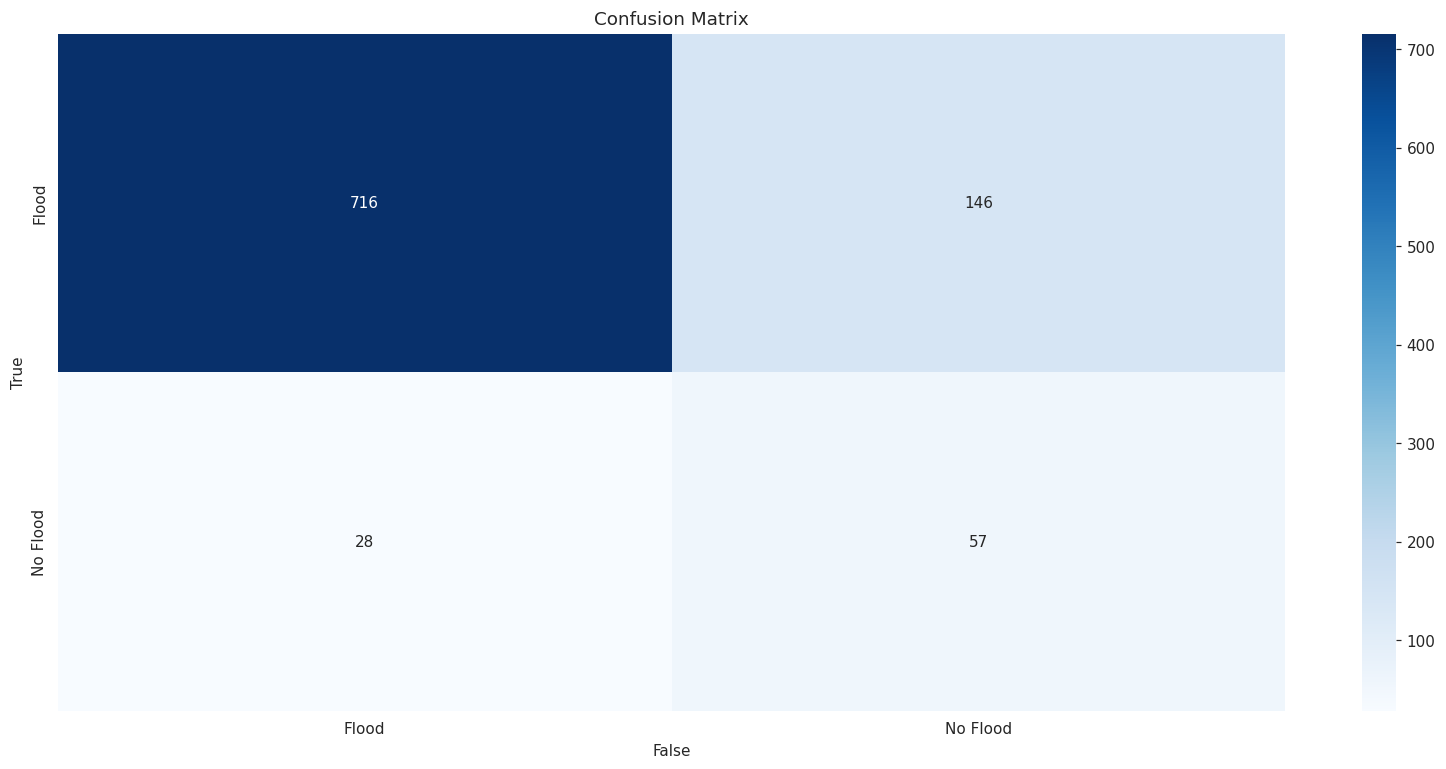

In [27]:
cm = confusion_matrix(y_test, test_pred)
label = ['Flood', 'No Flood']

plt.figure(figsize=(18, 8))
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label, yticklabels=label)
plt.ylabel("True")
plt.xlabel("False")

plt.show()

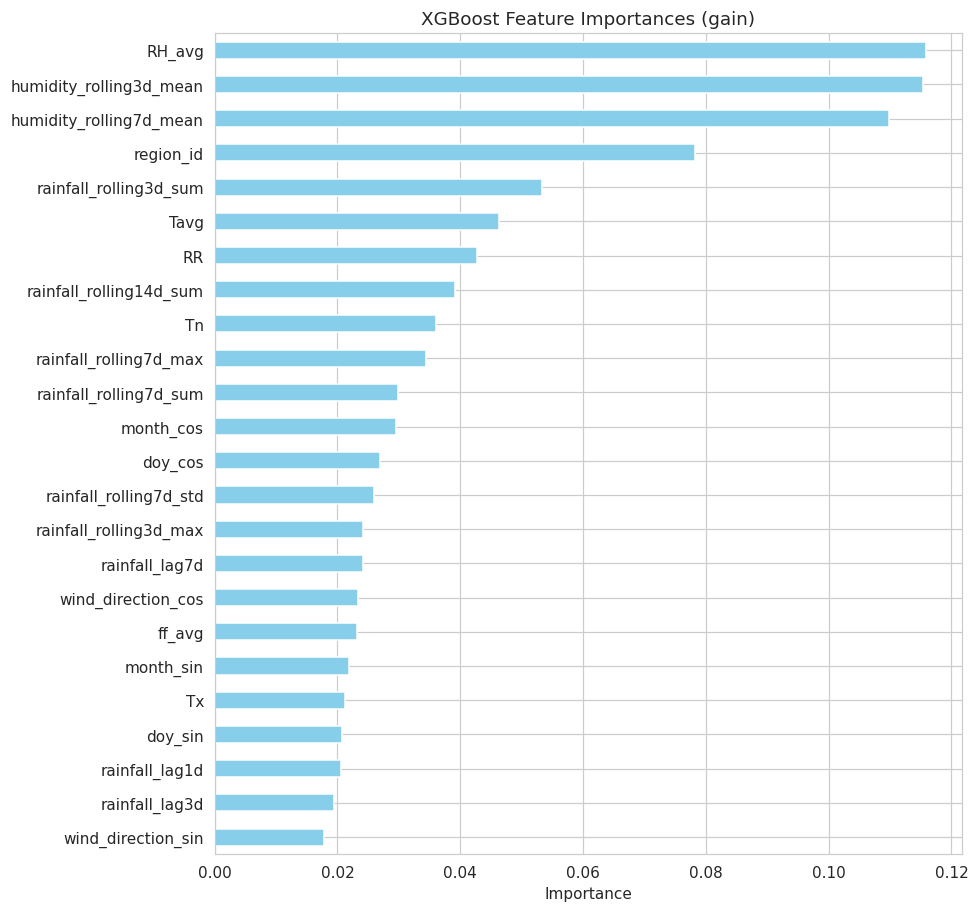

In [28]:
importances = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COL
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURE_COL)*0.35)))
importances.plot.barh(ax=ax, color="skyblue")
ax.set_title("XGBoost Feature Importances (gain)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [29]:
model_data = {
    'le_region': le_region,
    'region_map': {k: int(v) for k, v in region_map.items()},
    'feature_cols': FEATURE_COL,
    'scaler': scaler,
    'flood_model': final_model,
    'best_params': best_params
}

with open(MODEL_DIR / "model_data.pkl", "wb") as f:
    pickle.dump(model_data, f)